## Calculate alpha density using Matti's quadratic

In [1]:
# Reload Process each time (keep editable install up-to-date)
%load_ext autoreload
%autoreload 2
from IPython.display import clear_output
from process.main import SingleRun
import process.data_structure
import process.impurity_radiation as impurity_radiation
import process.constraints
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import matplotlib.colors
import process.physics
import pandas as pd
import seaborn as sns
from process.io.plot_solutions import (
    RunMetadata,
    plot_mfile_solutions,
    plot_mfile_solutions_constraints,
)
from pathlib import Path

Running scipy's SLSQP


## Test with real values
Run solution file to get realistic values for inputs to Matti's calc.

Run to get final values for original large tokamak solution evaluation, then put into new n_alpha calculation.

In [2]:
# Set up
INPUT_FILE = "data/lt_tau_alpha_sol_eval_IN.DAT"
single_run = SingleRun(INPUT_FILE)
process.data_structure.impurity_radiation_module.f_nd_impurity_electron_array[13] = (
    5.0e-6
)
process.data_structure.current_drive_variables.p_hcd_primary_extra_heat_mw = 200.0
impurity_radiation.rho_fix = True
process.data_structure.impurity_radiation_module.f_p_plasma_core_rad_reduction = 1.0
impurity_radiation.int_edge_rad = True
process.data_structure.physics_variables.i_rad_loss = 0
process.physics.old_n_alpha_calc = False
# Current n_alpha calc
process.physics.current_n_alpha_calc = True
process.physics.mattis_test = False
process.physics.eval_count = 0

ne = 6.0e19
te = 10.0
process.data_structure.physics_variables.dene = ne
process.data_structure.physics_variables.te = te

single_run.run()
clear_output()
proton_rate_density = process.data_structure.physics_variables.proton_rate_density
fusden_plasma_alpha = process.data_structure.physics_variables.fusden_plasma_alpha
znimp = single_run.models.physics.znimp
t_energy_confinement = process.data_structure.physics_variables.t_energy_confinement
nd_beam_ions = process.data_structure.physics_variables.nd_beam_ions
nd_fuel_ions = process.data_structure.physics_variables.nd_fuel_ions
print(f"{proton_rate_density/ne**2 = :.3e}")
print(f"{fusden_plasma_alpha/ne**2 = :.3e}")
print(f"{znimp/ne= :.3e}")
print(f"{t_energy_confinement = :.3e}")
print(f"{nd_beam_ions = :.3e}")
print(f"{nd_fuel_ions = :.3e}")

proton_rate_density/ne**2 = 6.816e-26
fusden_plasma_alpha/ne**2 = 2.593e-23
znimp/ne= 3.444e-02
t_energy_confinement = 5.353e+00
nd_beam_ions = 0.000e+00
nd_fuel_ions = 5.293e+19


In [3]:
n_alpha_lt = process.data_structure.physics_variables.nd_alphas
print(f"Original LT solution n_alpha = {n_alpha_lt:.3e}")
# Values from final eval of LT run
z_he = 2
t_alpha_t_energy_ratio = 5
# Matti's equation
a = (
    ne
    * t_alpha_t_energy_ratio
    * t_energy_confinement
    * (fusden_plasma_alpha / (nd_fuel_ions) ** 2)
)
b = 1 - (nd_beam_ions / ne) - (znimp / ne)
c = z_he + (proton_rate_density / fusden_plasma_alpha)
quad = np.polynomial.Polynomial((b**2 / c**2, ((-2 * a * b * c) - 1) / (a * c**2), 1))
print(f"roots = {quad.roots()}")
n_alpha_calc = quad.roots()[0] * ne
print(f"n_alpha = {n_alpha_calc:.3e}")

Original LT solution n_alpha = 2.499e+18
roots = [0.04164304 5.58234183]
n_alpha = 2.499e+18


This calculated n_alpha using the new equation is similar to the original value. This shows that the calculation perhaps isn't too far off what Process currently produces.

However, Matti's equation defines rates of production as being ne normalised (they use density fractions), therefore Process values (using absolute densities) need to be ne normalised too. However, for true values, the rates should be normalised over teh density profile before integration, rather than normalised using the volume-averaged density, as performed above. This will be considered later.

## Put into Process: single evaluation
Try single run to get quadratic solution for nd_alphas.

In [4]:
# Remove previous run's output
Path.unlink("n_alpha.csv")


def eval_cons(ne, te):
    # Set up
    single_run = SingleRun(INPUT_FILE)
    process.data_structure.impurity_radiation_module.f_nd_impurity_electron_array[
        13
    ] = 5.0e-6
    process.data_structure.current_drive_variables.p_hcd_primary_extra_heat_mw = 200.0
    impurity_radiation.rho_fix = True
    process.data_structure.impurity_radiation_module.f_p_plasma_core_rad_reduction = 1.0
    impurity_radiation.int_edge_rad = True
    process.data_structure.physics_variables.i_rad_loss = 0
    process.physics.old_n_alpha_calc = False
    process.physics.current_n_alpha_calc = False
    process.physics.mattis_test = False
    process.physics.eval_count = 0

    # Modifications for each run
    process.data_structure.physics_variables.dene = ne
    process.data_structure.physics_variables.te = te

    single_run.run()
    n_alpha = process.data_structure.physics_variables.nd_alphas
    return n_alpha


ne_grid, te_grid = np.meshgrid(ne, te)
eval_cons_vec = np.vectorize(pyfunc=eval_cons)
n_alpha = eval_cons_vec(ne_grid, te_grid)
clear_output()
n_alpha_value = n_alpha[0].item()
print(f"Original LT solution n_alpha = {n_alpha_lt:.3e}")
print(f"{n_alpha_value = :.3e}")
print(f"{n_alpha_value / ne = :.3e}")

# print(
#     f"{process.data_structure.physics_variables.proton_rate_density/process.data_structure.physics_variables.dene**2 = :.3e}"
# )
# print(
#     f"{process.data_structure.physics_variables.fusden_plasma_alpha/process.data_structure.physics_variables.dene**2 = :.3e}"
# )
# print(
#     f"{single_run.models.physics.znimp/process.data_structure.physics_variables.dene = :.3e}"
# )
# print(f"{process.data_structure.physics_variables.t_alpha_confinement = :.3e}")
# print(f"{process.data_structure.physics_variables.nd_beam_ions = :.3e}")
# print(
#     f"{process.data_structure.physics_variables.t_alpha_confinement/process.data_structure.physics_variables.t_energy_confinement = :.3e}"
# )

Original LT solution n_alpha = 2.499e+18
n_alpha_value = 2.499e+18
n_alpha_value / ne = 4.164e-02


This value of n_alpha is 3% of ne now, much closer to the original LT solution value of 2.626e+18. Plotting beta FPP iterations.

In [5]:
n_alpha_df = pd.read_csv("n_alpha.csv")
n_alpha_df_reset = n_alpha_df.reset_index(names="iteration")
n_alpha_df_melt = n_alpha_df_reset.melt(id_vars="iteration")
n_alpha_df_melt

,iteration,variable,value
0,0,n_alpha,4.000000e+18
1,1,n_alpha,2.712835e+18
2,2,n_alpha,2.527197e+18
3,3,n_alpha,2.502369e+18
4,4,n_alpha,2.499083e+18
...,...,...,...
61,17,tau_alpha/tau_E,5.000137e+00
62,18,tau_alpha/tau_E,5.000018e+00
63,19,tau_alpha/tau_E,5.000002e+00
64,20,tau_alpha/tau_E,5.000000e+00


In [6]:
# %matplotlib inline
fig, ax = plt.subplots()
ax = sns.relplot(
    data=n_alpha_df_melt,
    x="iteration",
    y="value",
    col="variable",
    facet_kws=dict(sharey=False),
)
# fig.show()

Weird. Some feedback thing going on inside beta FPP loop.

## Evaluate n_alpha and constraints
How does n_alpha vary in the te, ne parameter space?

In [7]:
# Common process set up
input_file = "data/lt_tau_alpha_sol_eval_IN.DAT"
single_run = SingleRun(input_file)
process.data_structure.impurity_radiation_module.f_nd_impurity_electron_array[13] = (
    5.0e-6
)
impurity_radiation.rho_fix = True
impurity_radiation.int_edge_rad = True
process.physics.old_n_alpha_calc = False
process.physics.current_n_alpha_calc = False
process.physics.mattis_test = False

# Study set up
N = 10
ne = np.linspace(9.0e18, 1.0e20, num=N)
te = np.linspace(4.0, 20.0, num=N)
ne_grid, te_grid = np.meshgrid(ne, te)


# Evaluation func
def eval_n_alpha(ne, te):
    single_run = SingleRun(input_file)
    # Loading single run overwrites variables: set again
    process.data_structure.current_drive_variables.p_hcd_primary_extra_heat_mw = 600.0
    process.data_structure.physics_variables.hfact = 1.0
    process.data_structure.physics_variables.i_rad_loss = 1
    process.data_structure.impurity_radiation_module.f_p_plasma_core_rad_reduction = 1.0

    process.data_structure.physics_variables.dene = ne
    process.data_structure.physics_variables.te = te
    process.physics.eval_count = 0
    # Bad idea, but try to get to solve
    process.data_structure.constraint_variables.f_alpha_energy_confinement_min = 5.0

    try:
        # Handle failed runs
        single_run.run()
    except Exception as e:
        return np.nan, np.nan, np.nan, np.nan, np.nan, e

    return (
        process.constraints.constraint_equation_2().normalised_residual,
        process.constraints.constraint_equation_62().normalised_residual,
        process.data_structure.physics_variables.nd_alphas,
        process.data_structure.physics_variables.t_alpha_confinement,
        process.data_structure.physics_variables.t_energy_confinement,
        "",
    )


def make_df(con2, con62, nd_alphas, tau_alpha, tau_E, e):
    return pd.DataFrame(
        {
            "ne": ne_grid.flatten(),
            "te": te_grid.flatten(),
            "ppb_con": con2.flatten(),
            "tau_alpha_con": con62.flatten(),
            "nd_alphas": nd_alphas.flatten(),
            "tau_alpha": tau_alpha.flatten(),
            "tau_E": tau_E.flatten(),
            "error": e.flatten(),
        }
    )


eval_n_alpha_vec = np.vectorize(pyfunc=eval_n_alpha)
clear_output()


In [8]:
process.physics.old_n_alpha_calc = False
process.physics.current_n_alpha_calc = False
process.physics.eval_count = 0
con2, con62, n_alpha, tau_alpha, tau_E, e = eval_n_alpha_vec(ne_grid, te_grid)
clear_output()
make_df(con2, con62, n_alpha, tau_alpha, tau_E, e)

,ne,te,ppb_con,tau_alpha_con,nd_alphas,tau_alpha,tau_E,error
0,9.000000e+18,4.0,0.899849,-6.661338e-16,1.865375e+16,4.683109,0.936622,
1,1.911111e+19,4.0,0.833871,0.000000e+00,1.832050e+16,4.578232,0.915646,
2,2.922222e+19,4.0,0.768963,-6.661338e-16,1.794897e+16,4.478992,0.895798,
3,3.933333e+19,4.0,0.698900,-4.440892e-16,2.320345e+16,5.163030,1.032606,
4,4.944444e+19,4.0,0.531788,-4.440892e-16,3.884841e+16,7.003554,1.400711,
...,...,...,...,...,...,...,...,...
95,5.955556e+19,20.0,-0.146761,-5.029310e-13,1.593506e+18,5.888834,1.177767,
96,6.966667e+19,20.0,-0.236450,-3.447020e-11,2.499146e+18,6.018546,1.203709,
97,7.977778e+19,20.0,-0.294470,-2.157987e-10,3.492303e+18,5.934148,1.186830,
98,8.988889e+19,20.0,-0.335493,2.148359e-11,4.558588e+18,5.779856,1.155971,


Often get 2 physical roots: 0.45 and 0.51.

/tmp/ipykernel_545928/1582867608.py:12: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


Text(0.5, 1.0, '$n_\\alpha$ against $n_e$ and $T_e$')

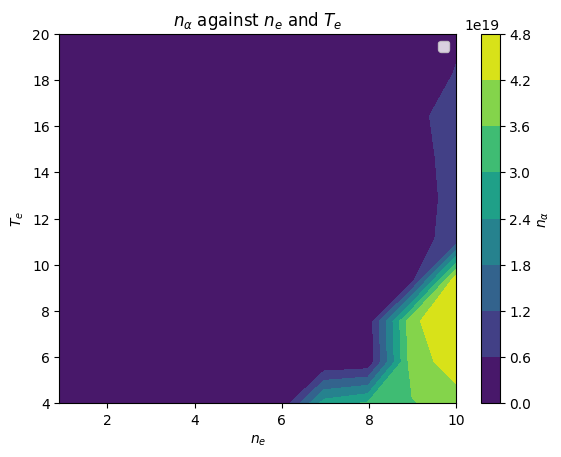

In [16]:
%matplotlib inline
fig, ax = plt.subplots()
contour = ax.contourf(
    (ne_grid * 1e-19),
    te_grid,
    n_alpha,
    # locator=matplotlib.ticker.LogLocator(),
)
fig.colorbar(contour, ax=ax, label=r"$n_\alpha$")
ax.set_xlabel("$n_e$")
ax.set_ylabel("$T_e$")
ax.legend()
# ax.scatter(ne_grid, te_grid)
# ax.set_xlim(3e19,8e19)
ax.set_title(r"$n_\alpha$ against $n_e$ and $T_e$")

n_alpha seems quite high. What's failing in the gaps? Most failures are due to znfuel becoming negative. 

Upping ne to higher range: still large gaps. Not just a case of increasing ne.

Debug one.

## Debugging failures
Take failing te, ne from dataframe (negative znfuel) and debug.

In [10]:
# # Common process set up
# input_file = "data/lt_tau_alpha_sol_eval_IN.DAT"
# single_run = SingleRun(input_file)
# process.data_structure.impurity_radiation_module.f_nd_impurity_electron_array[13] = (
#     5.0e-6
# )
# process.data_structure.current_drive_variables.p_hcd_primary_extra_heat_mw = 200.0
# impurity_radiation.rho_fix = True
# process.data_structure.impurity_radiation_module.f_p_plasma_core_rad_reduction = 1.0
# impurity_radiation.int_edge_rad = True
# process.data_structure.physics_variables.i_rad_loss = 0

# # Individual run
# single_run = SingleRun(input_file)
# process.data_structure.physics_variables.dene = 10.142857142857143e19
# process.data_structure.physics_variables.te = 7.0
# process.physics.eval_count = 0

# single_run.run()


Increasing ne solved the problem: znfuel is now positive.

## Plotting taus

/tmp/ipykernel_545928/1766177143.py:12: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axs[0].legend()
/tmp/ipykernel_545928/1766177143.py:30: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axs[1].legend()


Text(0.5, 0.98, '$\\tau_\\alpha / \\tau_E$')

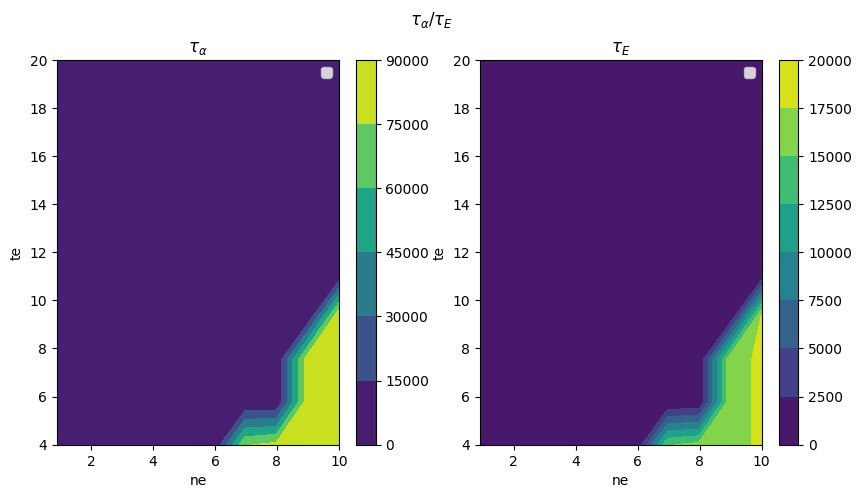

In [11]:
%matplotlib inline
fig, axs = plt.subplots(ncols=2)
fig.set_size_inches(10, 5)
contour = axs[0].contourf(
    (ne_grid * 1e-19),
    te_grid,
    tau_alpha,
)
fig.colorbar(contour, ax=axs[0])
axs[0].set_xlabel("ne")
axs[0].set_ylabel("te")
axs[0].legend()
cs = axs[0].contour(
    (ne_grid * 1e-19),
    te_grid,
    tau_alpha,
    levels=[0.0],
    colors="red",
)
axs[0].clabel(cs)
# Second plot
contour = axs[1].contourf(
    (ne_grid * 1e-19),
    te_grid,
    tau_E,
)
fig.colorbar(contour, ax=axs[1])
axs[1].set_xlabel("ne")
axs[1].set_ylabel("te")
axs[1].legend()
cs = axs[1].contour(
    (ne_grid * 1e-19),
    te_grid,
    tau_E,
    levels=[0.0],
    colors="red",
)
axs[1].clabel(cs)
axs[0].set_title(r"$\tau_\alpha$")
axs[1].set_title(r"$\tau_E$")
fig.suptitle(r"$\tau_\alpha / \tau_E$")

Try turning up p_hcd_primary_extra_heat_mw to 300: should reduce tau_E from max of 2e4.

/tmp/ipykernel_545928/1479178488.py:12: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axs[0].legend()
/tmp/ipykernel_545928/1479178488.py:30: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axs[1].legend()


Text(0.5, 0.98, 'Constraint evaluations')

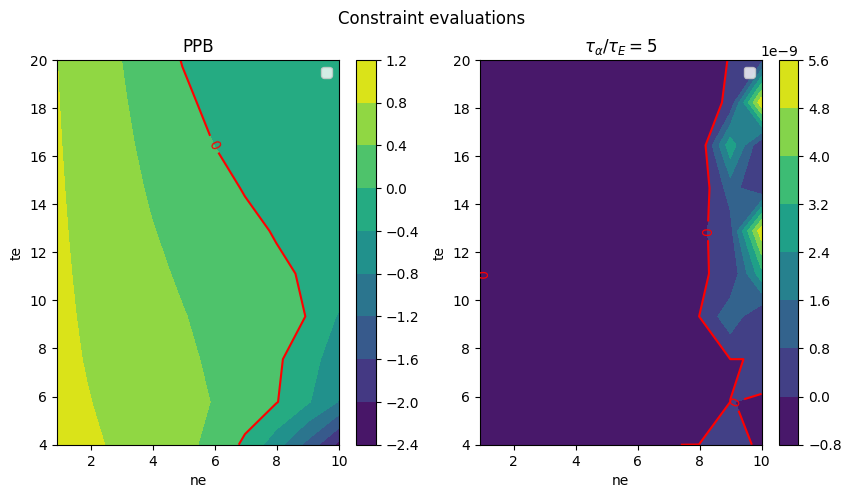

In [12]:
%matplotlib inline
fig, axs = plt.subplots(ncols=2)
fig.set_size_inches(10, 5)
contour = axs[0].contourf(
    (ne_grid * 1e-19),
    te_grid,
    con2,
)
fig.colorbar(contour, ax=axs[0])
axs[0].set_xlabel("ne")
axs[0].set_ylabel("te")
axs[0].legend()
cs = axs[0].contour(
    (ne_grid * 1e-19),
    te_grid,
    con2,
    levels=[0.0],
    colors="red",
)
axs[0].clabel(cs)
# Second plot
contour = axs[1].contourf(
    (ne_grid * 1e-19),
    te_grid,
    con62,
)
fig.colorbar(contour, ax=axs[1])
axs[1].set_xlabel("ne")
axs[1].set_ylabel("te")
axs[1].legend()
cs = axs[1].contour(
    (ne_grid * 1e-19),
    te_grid,
    con62,
    levels=[0.0],
    colors="red",
)
axs[1].clabel(cs)
axs[0].set_title("PPB")
axs[1].set_title(r"$\tau_\alpha / \tau_E = 5$")
fig.suptitle("Constraint evaluations")

PPB looks fine. tau_alpha constraint now has a gradient, but strange shape.

## Solutions

In [13]:
# # Upgrade to Sobol?
# INPUT_FILE = "data/lt_tau_alpha_sol_solve_IN.DAT"


# def solve(ne, te):
#     # Set up
#     single_run = SingleRun(INPUT_FILE)
#     # Loading single run overwrites variables: set again
#     process.data_structure.current_drive_variables.p_hcd_primary_extra_heat_mw = 600.0
#     process.data_structure.physics_variables.hfact = 1.0
#     process.data_structure.physics_variables.i_rad_loss = 1
#     process.data_structure.impurity_radiation_module.f_p_plasma_core_rad_reduction = 1.0

#     process.data_structure.physics_variables.dene = ne
#     process.data_structure.physics_variables.te = te
#     process.physics.eval_count = 0
#     # Bad idea, but try to get to solve
#     process.data_structure.constraint_variables.f_alpha_energy_confinement_min = 4.0

#     try:
#         # Handle failed runs
#         single_run.run()
#     except Exception:
#         return None, None

#     if single_run.scan.ifail != 1:
#         return None, None

#     return (
#         process.data_structure.physics_variables.dene,
#         process.data_structure.physics_variables.te,
#     )


# N = 5
# ne = np.linspace(4.0e19, 1.2e20, num=N)
# te = np.linspace(7.0, 16.0, num=N)
# ne_grid, te_grid = np.meshgrid(ne, te)
# solve_vec = np.vectorize(pyfunc=solve)
# ne_sol, te_sol = solve_vec(ne_grid, te_grid)
# clear_output()


In [14]:
sol_df = pd.DataFrame(
    {
        "ne_init": ne_grid.flatten(),
        "te_init": te_grid.flatten(),
        "ne_sol": ne_sol.flatten(),
        "te_sol": te_sol.flatten(),
    }
)
sol_df

NameError: name 'ne_sol' is not defined

In [ ]:
fig, ax = plt.subplots()
# Filter initial points that didn't converge
sols = sol_df[sol_df["te_sol"].notnull()]
failed_sols = sol_df[sol_df["te_sol"].isnull()]
ax.scatter(sols["ne_init"], sols["te_init"], c="green", label="Solutions: initial")
ax.scatter(sols["ne_sol"], sols["te_sol"], c="red", label="Solutions: final")
ax.scatter(
    failed_sols["ne_init"],
    failed_sols["te_init"],
    c="grey",
    label="Failed solutions: initial",
)
ax.set_xlabel("ne")
ax.set_ylabel("te")
ax.legend()

In [ ]:
sols_melt = sols[["ne_sol", "te_sol"]].melt()
sols_melt
ax = sns.displot(
    data=sols_melt, col="variable", x="value", facet_kws=dict(sharex=False)
)